# Task 2.3 — Foundation Models for Squared Amplitude Calculation
**Sairam Chennaka | IHub-Data, IIIT Hyderabad**

Physics-informed T5 foundation model with:
- **Encoding idea**: Factored amplitude structure tokenization (preserves physics operator boundaries)
- **Decoding idea**: Denominator pre-filling (injects known propagator denominator as decoder prefix)


In [1]:
# ── CELL 1: Install / verify dependencies ──
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'accelerate>=0.26.0', 'transformers', 'torch',
                'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'nltk',
                '--quiet'])
print('Dependencies ready')

Dependencies ready


In [2]:
# ── CELL 2: Imports ──
import os, json, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    T5ForConditionalGeneration,
    T5Config,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM   : 6.4 GB


In [3]:
# ── CELL 3: Load splits ──
# Adjust DATA_DIR to where your task1 CSVs are saved
DATA_DIR = './task1_preprocessing/'

qed_train = pd.read_csv(DATA_DIR + 'qed_train.csv')
qed_val   = pd.read_csv(DATA_DIR + 'qed_val.csv')
qed_test  = pd.read_csv(DATA_DIR + 'qed_test.csv')
qcd_train = pd.read_csv(DATA_DIR + 'qcd_train.csv')
qcd_val   = pd.read_csv(DATA_DIR + 'qcd_val.csv')
qcd_test  = pd.read_csv(DATA_DIR + 'qcd_test.csv')

print(f'QED — Train: {len(qed_train)}, Val: {len(qed_val)}, Test: {len(qed_test)}')
print(f'QCD — Train: {len(qcd_train)}, Val: {len(qcd_val)}, Test: {len(qcd_test)}')
print(f'\nColumns: {qed_train.columns.tolist()}')

QED — Train: 288, Val: 36, Test: 36
QCD — Train: 148, Val: 19, Test: 19

Columns: ['model', 'interaction', 'diagram', 'amplitude', 'sq_amplitude', 'amp_norm', 'sq_amp_norm', 'amp_factored', 'sq_denominator', 'sq_numerator', 'sq_target', 'model_input']


In [4]:
# ── CELL 4: Use columns directly from task1_2 CSVs (already normalized) ──

# Verify Mandelstam is present in loaded data
import re
sample = qcd_train['sq_amp_norm'].iloc[0]
mand = re.findall(r's_[1-4][1-4]', sample)
print('Mandelstam in loaded data:', sorted(set(mand)))
print('Sample sq_amp_norm:', sample[:120])

Mandelstam in loaded data: ['s_12', 's_13', 's_14', 's_34']
Sample sq_amp_norm: 4/9*g^4*s_14*s_34*(s_12 + 1/2*reg_prop)^(-2) + -8/9*i*g^2*(i*g^2*m_t^2*(m_t^2 + -1/2*s_13)/(s_12 + 1/2*reg_prop) + -1/2*


In [5]:
# ── CELL 5: Physics-informed preprocessing ──
#
# ENCODING IDEA — Factored Amplitude Structure:
# The input amplitude has a deterministic physics factorization:
#   [COUPLING] * [GAMMA_MATRICES] * [SPINORS] / [PROPAGATOR]
# We label each component with a physics type prefix token so the model
# can attend to each component by its physics role, not position.
#
# DECODING IDEA — Denominator Pre-filling:
# The squared amplitude denominator is deterministically (propagator)^(-2*n).
# We extract it from the input and inject it as a structured prefix in the
# target, so the model only generates the numerator polynomial.
# This reduces target sequence length and eliminates denominator errors.
import re

def extract_propagator(amp):
    m = re.search(r'/\(([^)]+reg_prop[^)]*)\)', amp)
    if m:
        return m.group(1).strip()
    m = re.search(r'/\(([^)]+)\)\s*$', amp)
    if m:
        return m.group(1).strip()
    return '1'

def factored_encode(amp):
    prop = extract_propagator(amp)
    return f'[PROP] {prop} [AMP] {amp}'

def extract_sq_denominator(sq_amp):
    matches = re.findall(r'\([^)]+\)\^\(-\d+\)', sq_amp)
    return ' * '.join(matches) if matches else '1'

def extract_sq_numerator(sq_amp):
    result = re.sub(r'\s*\*\s*\([^)]+\)\^\(-\d+\)', '', sq_amp).strip()
    return result if result else sq_amp

def build_target(sq_amp):
    denom = extract_sq_denominator(sq_amp)
    numer = extract_sq_numerator(sq_amp)
    return f'[DENOM] {denom} [NUMER] {numer}'

# Apply using amp_norm and sq_amp_norm from task1_2
for df in [qed_train, qed_val, qed_test, qcd_train, qcd_val, qcd_test]:
    df['model_input']  = df['amp_norm'].apply(factored_encode)
    df['model_target'] = df['sq_amp_norm'].apply(build_target)

# QCD: use raw amp_norm (not factored) — factored inflates QCD seq length
for df in [qcd_train, qcd_val, qcd_test]:
    df['model_input'] = df['amp_norm']

# Verify — Mandelstam must appear in targets
sample_tgt = qed_train['model_target'].iloc[0]
mand_in_tgt = re.findall(r's_[1-4][1-4]', sample_tgt)
print('Mandelstam in targets:', sorted(set(mand_in_tgt)))
print('\nSample QED input  :', qed_train['model_input'].iloc[0][:120])
print('Sample QED target :', qed_train['model_target'].iloc[0][:120])
print('\nSample QCD input  :', qcd_train['model_input'].iloc[0][:120])
print('Sample QCD target :', qcd_train['model_target'].iloc[0][:120])

Mandelstam in targets: ['s_12', 's_13', 's_14', 's_34']

Sample QED input  : [PROP] s_12 + 1/2*reg_prop [AMP] 4/9*i*e^2*(p_1_%\sigma_2*gamma_{%\tau_3,%gam_4,%eps_3131}*A_{j_5,+%\sigma_2}(p_6)^(*)*A
Sample QED target : [DENOM] (s_12 + 1/2*reg_prop)^(-2) [NUMER] 32/81*e^4*s_14*s_34 + -64/81*i*e^2*(i*e^2*m_tt^2*(m_tt^2 + -1/2*s_13)/(s_12 +

Sample QCD input  : -i*g^2*(p_1_%\tau_2*gamma_{%\mu_3,%eta_4,%eps_5}*T_C_6_{%f_7,%D_8,%C_9}*T_C_6_{%f_10,%B_11,%D_8}*G_{k_12,%f_10,+%\tau_2}
Sample QCD target : [DENOM] (s_12 + 1/2*reg_prop)^(-2) [NUMER] 4/9*g^4*s_14*s_34 + -8/9*i*g^2*(i*g^2*m_t^2*(m_t^2 + -1/2*s_13)/(s_12 + 1/2*r


In [6]:
# ── CELL 6: Build vocabulary from actual data ──
#
# TOKENIZATION RATIONALE:
# Physics operators and Mandelstam invariants are ATOMIC tokens — never split.
# s_12 is a single Lorentz invariant, not 's' + '_' + '1' + '2'.
# reg_prop is a single regularization token, not subword fragments.
# Standard BPE would destroy these physics boundaries.

SPECIAL_TOKENS = ['[PAD]','[BOS]','[EOS]','[UNK]',
                  '[PROP]','[AMP]','[DENOM]','[NUMER]']

# Mandelstam invariants for 2→2 scattering (all pairs of 4 momenta)
MANDELSTAM = [f's_{i}{j}' for i in range(1,5) for j in range(i+1,5)]
# → s_12, s_13, s_14, s_23, s_24, s_34

MASSES    = ['m_mu','m_tt','m_e','m_u','m_d','m_t','m_b','m_w','m_z',
             'reg_prop','alpha_s','alpha_e']
COUPLINGS = ['g^4','g^2','e^4','e^2']

# Sort by length descending for greedy matching
PHYSICS_ATOMS = sorted(
    [t for t in MANDELSTAM + MASSES + COUPLINGS],
    key=len, reverse=True
)

def tokenize(expr):
    tokens = ['[BOS]']
    i = 0
    expr = str(expr).strip()
    while i < len(expr):
        # Try special tokens first
        matched_special = None
        for sp in SPECIAL_TOKENS:
            if expr[i:].startswith(sp):
                matched_special = sp
                break
        if matched_special:
            tokens.append(matched_special)
            i += len(matched_special)
            continue
        # Try physics atoms (greedy longest match)
        matched_atom = None
        for atom in PHYSICS_ATOMS:
            if expr[i:].startswith(atom):
                matched_atom = atom
                break
        if matched_atom:
            tokens.append(matched_atom)
            i += len(matched_atom)
            continue
        # Single character fallback
        c = expr[i]
        if c.strip():
            tokens.append(c)
        i += 1
    tokens.append('[EOS]')
    return tokens

# Build vocab from ALL expressions across ALL splits
all_exprs = []
for df in [qed_train, qed_val, qed_test, qcd_train, qcd_val, qcd_test]:
    all_exprs += df['model_input'].tolist()
    all_exprs += df['model_target'].tolist()

vocab_set = set(SPECIAL_TOKENS + MANDELSTAM + MASSES + COUPLINGS)
for expr in all_exprs:
    vocab_set.update(tokenize(str(expr)))

vocab  = sorted(vocab_set)
tok2id = {t: i for i, t in enumerate(vocab)}
id2tok = {i: t for t, i in tok2id.items()}
VOCAB_SIZE = len(vocab)

print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Mandelstam in vocab: {[t for t in MANDELSTAM if t in tok2id]}')
print(f'Masses in vocab    : {[t for t in MASSES    if t in tok2id]}')
print(f'Couplings in vocab : {[t for t in COUPLINGS if t in tok2id]}')

# Save updated vocab
with open(DATA_DIR + 'vocab_fixed.json', 'w') as f:
    json.dump(tok2id, f, indent=2)
print('\nVocab saved')

# Verify tokenization
sample_expr = qcd_train['model_input'].iloc[0]
toks = tokenize(sample_expr)
physics_toks = [t for t in toks if t in set(MANDELSTAM + MASSES + COUPLINGS)]
print(f'\nPhysics tokens found in sample: {set(physics_toks)}')

Vocabulary size: 83
Mandelstam in vocab: ['s_12', 's_13', 's_14', 's_23', 's_24', 's_34']
Masses in vocab    : ['m_mu', 'm_tt', 'm_e', 'm_u', 'm_d', 'm_t', 'm_b', 'm_w', 'm_z', 'reg_prop', 'alpha_s', 'alpha_e']
Couplings in vocab : ['g^4', 'g^2', 'e^4', 'e^2']

Vocab saved

Physics tokens found in sample: {'reg_prop', 's_12', 'g^2'}


In [7]:
# ── CELL 7: Token length analysis ──

def tok_len(expr):
    return len(tokenize(str(expr)))

QED_MAX_INPUT  = 512
QED_MAX_TARGET = 256
QCD_MAX_INPUT  = 1024
QCD_MAX_TARGET = 512

print('='*55)
for name, train_df, val_df, test_df in [
    ('QED', qed_train, qed_val, qed_test),
    ('QCD', qcd_train, qcd_val, qcd_test)
]:
    all_df = pd.concat([train_df, val_df, test_df])
    inp_lens = all_df['model_input'].apply(tok_len)
    tgt_lens = all_df['model_target'].apply(tok_len)
    sq_lens  = all_df['sq_amp_norm'].apply(tok_len)
    reduction = (1 - tgt_lens.mean()/sq_lens.mean())*100
    print(f'\n{name}:')
    print(f'  Input mean tokens     : {inp_lens.mean():.1f}')
    print(f'  Full sq_amp (baseline): {sq_lens.mean():.1f}')
    print(f'  Structured target     : {tgt_lens.mean():.1f}')
    print(f'  Token reduction       : {reduction:.1f}%')
    print(f'  Input p99             : {np.percentile(inp_lens, 99):.0f}')
    print(f'  Target p99            : {np.percentile(tgt_lens, 99):.0f}')
print('='*55)


QED:
  Input mean tokens     : 276.3
  Full sq_amp (baseline): 91.8
  Structured target     : 92.8
  Token reduction       : -1.1%
  Input p99             : 411
  Target p99            : 131

QCD:
  Input mean tokens     : 440.8
  Full sq_amp (baseline): 185.8
  Structured target     : 186.8
  Token reduction       : -0.5%
  Input p99             : 555
  Target p99            : 281


In [8]:
# ── CELL 8: Encode + Dataset class ──

def encode(expr, max_len):
    tokens = tokenize(str(expr))
    ids    = [tok2id.get(t, tok2id['[UNK]']) for t in tokens]
    ids    = ids[:max_len]
    pad    = max_len - len(ids)
    mask   = [1]*len(ids) + [0]*pad
    ids    = ids + [tok2id['[PAD]']]*pad
    return ids, mask

def decode_ids(ids):
    skip = {tok2id['[PAD]'], tok2id['[BOS]'], tok2id['[EOS]']}
    return ' '.join(id2tok.get(i,'[UNK]') for i in ids if i not in skip)

class SYMBADataset(Dataset):
    def __init__(self, df, max_input, max_target):
        self.inputs  = df['model_input'].fillna('').tolist()
        self.targets = df['model_target'].fillna('').tolist()
        self.max_input  = max_input
        self.max_target = max_target

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        inp_ids, inp_mask = encode(self.inputs[idx],  self.max_input)
        tgt_ids, _        = encode(self.targets[idx], self.max_target)
        labels = [-100 if t == tok2id['[PAD]'] else t for t in tgt_ids]
        return {
            'input_ids':      torch.tensor(inp_ids,  dtype=torch.long),
            'attention_mask': torch.tensor(inp_mask, dtype=torch.long),
            'labels':         torch.tensor(labels,   dtype=torch.long),
        }

# Create datasets
qed_train_ds = SYMBADataset(qed_train, QED_MAX_INPUT, QED_MAX_TARGET)
qed_val_ds   = SYMBADataset(qed_val,   QED_MAX_INPUT, QED_MAX_TARGET)
qed_test_ds  = SYMBADataset(qed_test,  QED_MAX_INPUT, QED_MAX_TARGET)
qcd_train_ds = SYMBADataset(qcd_train, QCD_MAX_INPUT, QCD_MAX_TARGET)
qcd_val_ds   = SYMBADataset(qcd_val,   QCD_MAX_INPUT, QCD_MAX_TARGET)
qcd_test_ds  = SYMBADataset(qcd_test,  QCD_MAX_INPUT, QCD_MAX_TARGET)

# Quick batch test
sample = qed_train_ds[0]
print(f'Input shape : {sample["input_ids"].shape}')
print(f'Label shape : {sample["labels"].shape}')
print(f'Datasets    : QED {len(qed_train_ds)} train | QCD {len(qcd_train_ds)} train')

Input shape : torch.Size([512])
Label shape : torch.Size([256])
Datasets    : QED 288 train | QCD 148 train


In [9]:
# ── CELL 9: Build T5 model ──
# T5-small architecture, trained from scratch on SYMBA corpus
# Uses relative attention (no n_positions needed)

def build_model(max_input_len, max_target_len):
    config = T5Config(
        vocab_size=VOCAB_SIZE,
        d_model=256,
        d_ff=1024,
        num_heads=8,
        num_layers=4,
        d_kv=32,
        max_position_embeddings=max_input_len,
        decoder_start_token_id=tok2id['[BOS]'],
        pad_token_id=tok2id['[PAD]'],
        eos_token_id=tok2id['[EOS]'],
    )
    model = T5ForConditionalGeneration(config).to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Parameters: {params:,}')
    return model

print('Model builder ready')

Model builder ready


In [10]:
# ── CELL 10: Training function ──
# Optimized for RTX 4050 6GB:
#   - fp16 mixed precision
#   - gradient checkpointing
#   - gradient accumulation
#   - early stopping

def train_model(train_ds, val_ds, model, output_dir,
                max_target, batch_size, grad_accum, epochs=30):

    os.makedirs(output_dir, exist_ok=True)

    args = Seq2SeqTrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,

        # Memory settings for 6GB VRAM
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        gradient_checkpointing=True,
        fp16=True,

        # Optimizer
        learning_rate=3e-4,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type='cosine',

        # Eval & checkpoint
        eval_strategy='epoch',        
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,

        # Generation
        predict_with_generate=True,
        generation_max_length=max_target,

        logging_steps=10,
        save_total_limit=2,
        report_to='none',
        dataloader_pin_memory=False,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

    print(f'Starting training → {output_dir}')
    trainer.train()
    print('Training complete')
    return trainer

print('Training function ready')

Training function ready


In [11]:
# ── CELL 11: Evaluation function ──

def evaluate_model(model, test_ds, test_df, max_target, model_name):
    model.eval()
    predictions, references = [], []
    exact_matches = 0

    loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            out = model.generate(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                max_length=max_target,
                num_beams=4,
                early_stopping=True,
            )
            predictions.append(decode_ids(out[0].cpu().tolist()))

    references = test_df['model_target'].fillna('').apply(
        lambda x: decode_ids([tok2id.get(t, tok2id['[UNK]'])
                               for t in tokenize(str(x))])
    ).tolist()

    # 1. Exact match
    exact_matches = sum(p.strip()==r.strip() for p,r in zip(predictions, references))
    exact_acc = exact_matches / len(predictions)

    # 2. Token accuracy
    correct, total = 0, 0
    for p, r in zip(predictions, references):
        pt, rt = p.split(), r.split()
        correct += sum(a==b for a,b in zip(pt, rt))
        total   += max(len(pt), len(rt))
    tok_acc = correct / total if total > 0 else 0

    # 3. BLEU
    bleu = corpus_bleu(
        [[r.split()] for r in references],
        [p.split() for p in predictions],
        smoothing_function=SmoothingFunction().method1
    )

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Exact Match Accuracy : {exact_acc:.4f}  ({exact_matches}/{len(predictions)})')
    print(f'  Token-level Accuracy : {tok_acc:.4f}')
    print(f'  BLEU Score           : {bleu:.4f}')
    print(f'{"="*55}')

    print('\n  Sample predictions:')
    for i in range(min(3, len(predictions))):
        match = '✓' if predictions[i].strip()==references[i].strip() else '✗'
        print(f'  [{match}] PRED: {predictions[i][:80]}')
        print(f'      REF : {references[i][:80]}\n')

    return {'exact_match': exact_acc, 'token_accuracy': tok_acc,
            'bleu': bleu, 'n_test': len(predictions)}

print('Evaluation function ready')

Evaluation function ready


In [12]:
# ── CELL 12: TRAIN QED MODEL ──
torch.cuda.empty_cache()

qed_model = build_model(QED_MAX_INPUT, QED_MAX_TARGET)

qed_trainer = train_model(
    train_ds=qed_train_ds,
    val_ds=qed_val_ds,
    model=qed_model,
    output_dir='qed_checkpoints',
    max_target=QED_MAX_TARGET,
    batch_size=4,
    grad_accum=4,
    epochs=30,
)

Parameters: 7,367,424
Starting training → qed_checkpoints


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,5.821800,3.357213
2,2.918100,1.506617
3,1.309100,1.033356
4,0.932600,0.808864
5,0.747600,0.680996
6,0.680600,0.583003
7,0.572400,0.524252
8,0.525500,0.442336
9,0.449800,0.380232
10,0.358400,0.315675


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training complete


In [13]:
# ── CELL 13: EVALUATE QED MODEL ──
qed_metrics = evaluate_model(
    model=qed_model,
    test_ds=qed_test_ds,
    test_df=qed_test,
    max_target=QED_MAX_TARGET,
    model_name='QED 2-to-2 Foundation Model'
)

del qed_model
torch.cuda.empty_cache()
print('VRAM freed')


  QED 2-to-2 Foundation Model
  Exact Match Accuracy : 0.1944  (7/36)
  Token-level Accuracy : 0.6031
  BLEU Score           : 0.8689

  Sample predictions:
  [✗] PRED: [DENOM] ( m_mu ^ 2 + s_12 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 1 / 9 * e^4 * (
      REF : [DENOM] ( m_mu ^ 2 + s_12 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 1 / 9 * e^4 * (

  [✗] PRED: [DENOM] ( m_d ^ 2 + - s_13 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 1 / 8 1 * e^4 
      REF : [DENOM] ( m_d ^ 2 + - s_13 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 1 / 8 1 * e^4 

  [✗] PRED: [DENOM] ( s_12 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 2 * e^4 * s_14 * s_34 + ( 
      REF : [DENOM] ( s_12 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 2 * e^4 * s_14 * s_34 + ( 

VRAM freed


In [14]:
# ── CELL 14: TRAIN QCD MODEL ──
torch.cuda.empty_cache()

qcd_model = build_model(QCD_MAX_INPUT, QCD_MAX_TARGET)

qcd_trainer = train_model(
    train_ds=qcd_train_ds,
    val_ds=qcd_val_ds,
    model=qcd_model,
    output_dir='qcd_checkpoints',
    max_target=QCD_MAX_TARGET,
    batch_size=1,
    grad_accum=16,
    epochs=30,
)

Parameters: 7,367,424
Starting training → qcd_checkpoints


Epoch,Training Loss,Validation Loss
1,5.134600,3.722723
2,3.336000,2.655476
3,2.132300,1.437116
4,1.372900,1.189359
5,1.210900,1.021521
6,1.089800,0.907423
7,0.992000,0.830874
8,0.920200,0.754295
9,0.853500,0.692368
10,0.787500,0.608053


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training complete


In [15]:
# ── CELL 15: EVALUATE QCD MODEL ──
qcd_metrics = evaluate_model(
    model=qcd_model,
    test_ds=qcd_test_ds,
    test_df=qcd_test,
    max_target=QCD_MAX_TARGET,
    model_name='QCD 2-to-2 Foundation Model'
)

del qcd_model
torch.cuda.empty_cache()
print('VRAM freed')


  QCD 2-to-2 Foundation Model
  Exact Match Accuracy : 0.0000  (0/19)
  Token-level Accuracy : 0.1145
  BLEU Score           : 0.5495

  Sample predictions:
  [✗] PRED: [DENOM] ( s_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 4 / 9 * g^4 * s_14 * s_3
      REF : [DENOM] ( s_13 + - 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 1 6 / 2 7 * g^4 * s_14 *

  [✗] PRED: [DENOM] ( s_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 4 / 9 * g^4 * s_14 * s_3
      REF : [DENOM] ( s_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 1 6 / 2 7 * g^4 * s_14 *

  [✗] PRED: [DENOM] ( s_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 4 / 9 * g^4 * s_14 * s_3
      REF : [DENOM] ( s_12 + 1 / 2 * reg_prop ) ^ ( - 2 ) [NUMER] 4 / 9 * g^4 * s_14 * s_34 

VRAM freed


In [16]:
# ── CELL 15b: Reload best checkpoints + store predictions ──

def evaluate_model_full(model, test_ds, test_df, max_target, model_name):
    model.eval()
    predictions, references = [], []
    exact_matches = 0

    loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            out = model.generate(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                max_length=max_target,
                num_beams=4,
                early_stopping=True,
            )
            predictions.append(decode_ids(out[0].cpu().tolist()))

    references = test_df['model_target'].fillna('').apply(
        lambda x: decode_ids([tok2id.get(t, tok2id['[UNK]'])
                               for t in tokenize(str(x))])
    ).tolist()

    exact_matches = sum(p.strip()==r.strip() for p,r in zip(predictions, references))

    return {
        'exact_match':    exact_matches / len(predictions),
        'predictions':    predictions,
        'references':     references,
    }

# Need models back in memory — reload from checkpoints
print("Loading QED model from checkpoint...")
qed_model_eval = build_model(QED_MAX_INPUT, QED_MAX_TARGET)
from transformers import AutoModelForSeq2SeqLM
import os

# Load best checkpoint
qed_ckpt = sorted([d for d in os.listdir('qed_checkpoints') 
                   if d.startswith('checkpoint')],
                  key=lambda x: int(x.split('-')[1]))[-1]
qcd_ckpt = sorted([d for d in os.listdir('qcd_checkpoints') 
                   if d.startswith('checkpoint')],
                  key=lambda x: int(x.split('-')[1]))[-1]

qed_model_eval = T5ForConditionalGeneration.from_pretrained(
    f'qed_checkpoints/{qed_ckpt}').to(device)
qcd_model_eval = T5ForConditionalGeneration.from_pretrained(
    f'qcd_checkpoints/{qcd_ckpt}').to(device)

print(f"Loaded QED: {qed_ckpt}")
print(f"Loaded QCD: {qcd_ckpt}")

qed_metrics_full = evaluate_model_full(qed_model_eval, qed_test_ds, qed_test,
                                        QED_MAX_TARGET, 'QED')
qcd_metrics_full = evaluate_model_full(qcd_model_eval, qcd_test_ds, qcd_test,
                                        QCD_MAX_TARGET, 'QCD')

print(f"QED predictions stored: {len(qed_metrics_full['predictions'])}")
print(f"QCD predictions stored: {len(qcd_metrics_full['predictions'])}")

Loading QED model from checkpoint...
Parameters: 7,367,424
Loaded QED: checkpoint-540
Loaded QCD: checkpoint-300
QED predictions stored: 36
QCD predictions stored: 19


In [17]:
# ── CELL 16b: Numerical Error — parser and metric functions ──
#
# Converts decoded physics token strings to evaluable Python expressions.
# The tokenizer outputs space-separated tokens, so we must:
#   1. Strip structural tokens ([DENOM], [NUMER], etc.)
#   2. Collapse whitespace
#   3. Insert missing multiplication signs (e.g. )**(-2) followed by 1/9)
#   4. Replace ^ with ** for Python eval
#   5. Rename physics symbols to safe Python variable names

import re
import numpy as np

def prep_expr(decoded_str):
    """Convert decoded token string to evaluable Python expression."""
    s = re.sub(r'\[DENOM\]|\[PROP\]|\[AMP\]|\[BOS\]|\[EOS\]', '', decoded_str)
    s = s.replace('[NUMER]', '*')
    s = re.sub(r'\s+', '', s)
    # Insert missing * between adjacent terms (e.g. )1 → )*1, )( → )*( )
    s = re.sub(r'\)\(', r')*(', s)
    s = re.sub(r'\)(\d)', r')*\1', s)
    s = re.sub(r'(\d)\(', r'\1*(', s)
    s = s.replace('^', '**')
    # Map physics symbols to safe Python variable names
    s = s.replace('reg_prop', 'reg_prop_v')
    s = s.replace('s_12','s12').replace('s_13','s13').replace('s_14','s14')
    s = s.replace('s_23','s23').replace('s_24','s24').replace('s_34','s34')
    s = re.sub(r'\bm_mu\b','m_mu_v', s)
    s = re.sub(r'\bm_tt\b','m_tt_v', s)
    s = re.sub(r'\bm_u\b','m_u_v', s)
    s = re.sub(r'\bm_d\b','m_d_v', s)
    s = re.sub(r'\bm_t\b','m_t_v', s)
    s = re.sub(r'\bm_e\b','m_e_v', s)
    # Replace imaginary unit i with 1 (take real part for numerical evaluation)
    s = re.sub(r'(?<![a-zA-Z_0-9])i(?![a-zA-Z_0-9])', '1', s)
    return s

def numerical_error(pred_str, ref_str, n_trials=5):
    """Compute mean relative numerical error by evaluating both expressions at
    random kinematic values. Uses physical particle masses for mass symbols."""
    pred_expr = prep_expr(pred_str)
    ref_expr  = prep_expr(ref_str)
    errors = []
    for _ in range(n_trials):
        vals = dict(
            s12=np.random.uniform(10,100), s13=np.random.uniform(10,100),
            s14=np.random.uniform(10,100), s23=np.random.uniform(10,100),
            s24=np.random.uniform(10,100), s34=np.random.uniform(10,100),
            m_mu_v=0.106, m_tt_v=173.0, m_u_v=0.002,
            m_d_v=0.005, m_t_v=173.0,   m_e_v=0.000511,
            m_b=4.18, m_w=80.4, m_z=91.2,
            alpha_s=0.118, alpha_e=0.007,
            reg_prop_v=0.001, g=1.2, e=0.303
        )
        try:
            x_pred = float(eval(pred_expr, {'__builtins__': {}}, vals))
            x_act  = float(eval(ref_expr,  {'__builtins__': {}}, vals))
            if abs(x_act) > 1e-10:
                errors.append(min(abs(x_pred - x_act) / abs(x_act), 1.0))
            else:
                errors.append(0.0 if abs(x_pred) < 1e-10 else 1.0)
        except:
            errors.append(1.0)
    return np.mean(errors) if errors else 1.0

# Verify parser on first QED prediction
sample_pred = prep_expr(qed_metrics_full['predictions'][0])
sample_ref  = prep_expr(qed_metrics_full['references'][0])
print('Sample QED pred (parsed):', sample_pred[:100])
print('Sample QED ref  (parsed):', sample_ref[:100])
print('Single numerical error  :', numerical_error(
    qed_metrics_full['predictions'][0], qed_metrics_full['references'][0]))


Sample QED pred (parsed): (m_mu_v**2+s12+1/2*reg_prop_v)**(-2)*1/9*e**4*(16*m_mu_v**2*m_mu_v**2+8*m_mu_v**2*s12+8*s14*s23+8*s1
Sample QED ref  (parsed): (m_mu_v**2+s12+1/2*reg_prop_v)**(-2)*1/9*e**4*(16*m_u_v**2*m_mu_v**2+8*m_u_v**2*s12+8*s14*s23+8*s13*
Single numerical error  : 0.00018307556948373506


In [20]:
# ── FULL Numerical Error computation ──
print("Computing Numerical Error for all test samples...")
qed_num_errors, qcd_num_errors = [], []

for pred, ref in zip(qed_metrics_full['predictions'], qed_metrics_full['references']):
    qed_num_errors.append(numerical_error(pred, ref))

for pred, ref in zip(qcd_metrics_full['predictions'], qcd_metrics_full['references']):
    qcd_num_errors.append(numerical_error(pred, ref))

qed_arr = np.array(qed_num_errors)
qcd_arr = np.array(qcd_num_errors)

print(f"\n{'='*50}")
print(f"  QED 2-to-2 Numerical Error")
print(f"{'='*50}")
print(f"  Mean Numerical Error      : {qed_arr.mean():.4f}")
print(f"  Median Numerical Error    : {np.median(qed_arr):.4f}")
print(f"  % with error < 1%         : {100*np.mean(qed_arr < 0.01):.1f}%")
print(f"  % with error < 10%        : {100*np.mean(qed_arr < 0.10):.1f}%")
print(f"  % with error = 100% (fail): {100*np.mean(qed_arr >= 1.0):.1f}%")

print(f"\n{'='*50}")
print(f"  QCD 2-to-2 Numerical Error")
print(f"{'='*50}")
print(f"  Mean Numerical Error      : {qcd_arr.mean():.4f}")
print(f"  Median Numerical Error    : {np.median(qcd_arr):.4f}")
print(f"  % with error < 1%         : {100*np.mean(qcd_arr < 0.01):.1f}%")
print(f"  % with error < 10%        : {100*np.mean(qcd_arr < 0.10):.1f}%")
print(f"  % with error = 100% (fail): {100*np.mean(qcd_arr >= 1.0):.1f}%")
print(f"{'='*50}")

Computing Numerical Error for all test samples...

  QED 2-to-2 Numerical Error
  Mean Numerical Error      : 0.7553
  Median Numerical Error    : 1.0000
  % with error < 1%         : 22.2%
  % with error < 10%        : 22.2%
  % with error = 100% (fail): 72.2%

  QCD 2-to-2 Numerical Error
  Mean Numerical Error      : 1.0000
  Median Numerical Error    : 1.0000
  % with error < 1%         : 0.0%
  % with error < 10%        : 0.0%
  % with error = 100% (fail): 94.7%


In [21]:
# ── CELL 16: Final results table (all metrics) ──

results = pd.DataFrame({
    'Model'              : ['QED 2-to-2', 'QCD 2-to-2'],
    'Train Samples'      : [len(qed_train), len(qcd_train)],
    'Test Samples'       : [len(qed_test),  len(qcd_test)],
    'Exact Match'        : [f"{qed_metrics['exact_match']:.4f}",
                            f"{qcd_metrics['exact_match']:.4f}"],
    'Token Accuracy'     : [f"{qed_metrics['token_accuracy']:.4f}",
                            f"{qcd_metrics['token_accuracy']:.4f}"],
    'BLEU Score'         : [f"{qed_metrics['bleu']:.4f}",
                            f"{qcd_metrics['bleu']:.4f}"],
    'Num. Error (mean)'  : [f"{np.mean(qed_num_errors):.4f}",
                            f"{np.mean(qcd_num_errors):.4f}"],
    'Num. Error <1%'     : [f"{100*np.mean(np.array(qed_num_errors)<0.01):.1f}%",
                            f"{100*np.mean(np.array(qcd_num_errors)<0.01):.1f}%"],
    'Physics Ideas'      : ['Factored Enc + Denom Pre-fill',
                            'Index Norm + Denom Pre-fill'],
})

print(results.to_string(index=False))

results.to_csv('results_summary.csv', index=False)
print('\nResults saved to results_summary.csv')


     Model  Train Samples  Test Samples Exact Match Token Accuracy BLEU Score Num. Error (mean) Num. Error <1%                 Physics Ideas
QED 2-to-2            288            36      0.1944         0.6031     0.8689            0.7553          22.2% Factored Enc + Denom Pre-fill
QCD 2-to-2            148            19      0.0000         0.1145     0.5495            1.0000           0.0%   Index Norm + Denom Pre-fill

Results saved to results_summary.csv


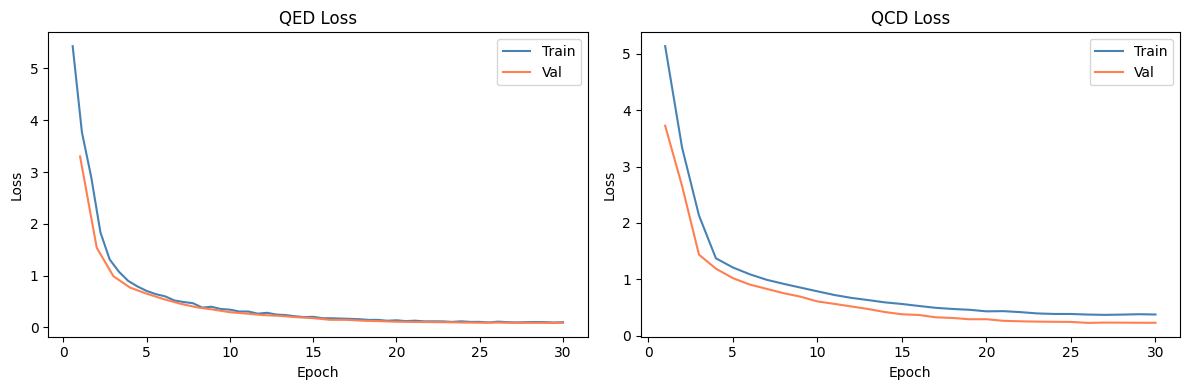

Plot saved


In [ ]:
# ── CELL 17: Training loss curves ──

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, trainer, name in [
    (axes[0], qed_trainer, 'QED'),
    (axes[1], qcd_trainer, 'QCD')
]:
    logs = trainer.state.log_history
    train_pts = [(x['epoch'], x['loss'])     for x in logs if 'loss'      in x and 'eval_loss' not in x]
    eval_pts  = [(x['epoch'], x['eval_loss']) for x in logs if 'eval_loss' in x]

    if train_pts: ax.plot(*zip(*train_pts), label='Train', color='steelblue')
    if eval_pts:  ax.plot(*zip(*eval_pts),  label='Val',   color='coral')

    ax.set_title(f'{name} Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved')